In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [2]:
model.invoke("hello world").content

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 16.719079091s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerM

### **Pydantic Schema**

In [ ]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):
    topic:str = Field(description = "The topic of the post")
    linkedin_post: str = Field(description = "The The curated caption for the linkedin post")
    x_post: str = Field(description = "The The curated caption for the X/twitter post")
    insta_post: str = Field(description = "The The curated caption for the Instagram post")

In [ ]:
def create_post_linkedin(state:graph_schema) -> graph_schema:

    topic = state.topic

    post = model.invoke(f"write a linkedin post on {topic}").content

    state.linkedin_post = post

    return {"linkedin_post": post}

In [ ]:
def create_post_x(state:graph_schema) -> graph_schema:

    topic = state.topic

    post = model.invoke(f"write a X/Twitter post on {topic}").content

    state.x_post = post

    return {"x_post":post}

In [ ]:
def create_post_insta(state:graph_schema) -> graph_schema:

    topic = state.topic

    post = model.invoke(f"write a Instagram post on {topic}").content

    state.insta_post = post

    return {"insta_post":post}

In [ ]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_linkedin",create_post_linkedin)
graph.add_node("create_post_x",create_post_x)


In [ ]:
graph.add_edge(START,"create_post_insta")
graph.add_edge(START,"create_post_linkedin")
graph.add_edge(START,"create_post_x")
graph.add_edge("create_post_insta",END)
graph.add_edge("create_post_linkedin",END)
graph.add_edge("create_post_x",END)

In [ ]:
ParallelGraph = graph.compile()

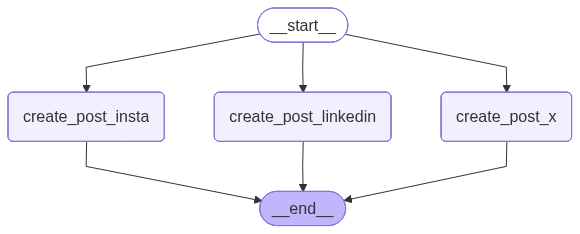

In [ ]:
from IPython.display import Image, display

Image(ParallelGraph.get_graph().draw_mermaid_png())

In [ ]:
ParallelGraph.invoke({
    "topic":"indian independence day",
    "linkedin_post":"",
    "x_post":"",
    "insta_post":""
})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 55.703714476s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerM